# NeoMME and ModernVBERT, side by side

> The same 100 digits and 80 photos, the same records and recipes, and two multimodal encoders under the sysone head: what each reads, what it costs, and where each is right.

- skip_exec: true
- skip_showdoc: true

sysone has two multimodal encoders, and each has a tutorial on the same two small image tasks: [NeoMME on images](neomme_images.ipynb) and [ModernVBERT on images](modernvbert_images.ipynb). This notebook runs both on identical inputs: the same records, drawn with the same seeds, the same splits, and the same head recipes. It then compares what they cost, how often they're right, how well their probabilities are calibrated, and where their mistakes fall.

| | NeoMME-260M | ModernVBERT |
| --- | --- | --- |
| Authors, licence | H company, Apache-2.0 | Illuin Technology, MIT |
| Architecture | one bidirectional encoder over text and page images, trained by masked diffusion | a ModernBERT text tower fed SigLIP2 image features (early fusion), trained by masked language modelling, then contrastively for retrieval |
| An image becomes | one token per 32-pixel patch, a `<row>` after each row of the grid, two-axis positions | 512-pixel tiles, each 32 × 32 SigLIP patches pixel-shuffled into 64 `<image>` tokens |
| Pretraining images | web pages and documents | documents, mostly, and natural images with captions |
| In sysone | an encoder of the multimodal application, its default until 2026-09-30 ([notebook](../20_neomme.ipynb)) | the multimodal application's default encoder since 2026-09-30, with its [adapter](../23_modernvbert.ipynb) |

::: {.callout-tip title="Jargon"}
- **Masked diffusion**: NeoMME's training. It learns to fill in text with a varying share of it masked, from a little to nearly all, so `<mask>` is the token it knows best.
- **Two-axis positions**: NeoMME gives each patch a row and a column, where a text model gives each token one position.
- **Patch stem**: NeoMME has no vision tower. A LayerNorm and a two-layer MLP turn each 32-pixel patch straight into a token, and the encoder's 17 layers read patches and words together.
- **Early fusion, pixel shuffle**: ModernVBERT runs a vision tower first (SigLIP2, 12 layers), folds each 4 × 4 block of its patch vectors into one token (the pixel shuffle), and feeds the tokens to its text encoder, ModernBERT, inside the row.
- **Contrastive training**: pulling matching images and texts together, and mismatched ones apart, which is how an encoder learns retrieval.
- **Anchor, head**: in a row, each option follows a mask token, its anchor. The head reads only the encoder's vectors at the anchors, standardised channel by channel, and scores each: Laya's scorer is a small MLP, the linear head a single weight vector. A softmax across the options, after a temperature fitted on held-out cases, gives the probabilities.
:::

The application keeps each encoder's defaults here. The encoder stays frozen with its anchors cached, and the heads train on standardised anchors: Laya's scorer for 30 epochs at 10⁻³, and the linear head by LBFGS. NeoMME reads the digits at two sizes, the 224 pixels of its tutorial's main runs and the 112 its tutorial's sweep found better. ModernVBERT reads everything as one 512-pixel tile, its default. The photos are 384 pixels for NeoMME, as in its tutorial, and one 512-pixel tile for ModernVBERT.

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). It needs both checkpoints, NeoMME-260M (526 MB) and ModernVBERT (1.2 GB), and the two datasets. Only one encoder is in memory at a time: each learner is deleted when its run is done. The whole run takes about two minutes on an M3 Pro (MPS, fp32), and the outputs below come from a run on 2026-09-27. It saves its images in `compare-images/`, next to the notebook.
:::

In [ ]:
import gc, io, json, logging, random, resource, shutil, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
from matplotlib.patches import Rectangle
from matplotlib_inline.backend_inline import set_matplotlib_formats
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, display
import datasets, huggingface_hub, transformers
from huggingface_hub import snapshot_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.core import collate
from sysone.data import TypedDecisions
from sysone.losses import answer_metrics, macro_f1
from sysone.multimodal import decision_learner

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.logging.set_verbosity_error(); huggingface_hub.utils.logging.set_verbosity_error()
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
import warnings; warnings.simplefilter("ignore", pd.errors.PerformanceWarning)      # .loc on the results' unsorted MultiIndex
data_dir = Path("compare-images")
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs (`learn.recorder` still has them)"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted learners"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def metrics(learn):
    "The held-out metrics worth a look, rounded"
    return {k: round(v, 3) for k, v in learn.validate().items() if k in ("accuracy", "soft_accuracy", "brier", "ece", "n")}

def memory_line():
    "The process's peak resident memory, and what the MPS driver holds now"
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (2**30 if sys.platform == "darwin" else 2**20)
    mps = f" · MPS {torch.mps.driver_allocated_memory() / 2**30:.1f} GB" if torch.backends.mps.is_available() else ""
    return f"peak RSS {rss:.1f} GB{mps}"

In [ ]:
#| code-fold: true
#| code-summary: plotting helpers
BLUE, LIGHT, TRACK, CARD, INK, GRAY = "#3b3ff5", "#9a9df7", "#d4d4d4", "#f2f2f2", "#111111", "#6b6b6b"

def show_figure(fig, fmt="png", dpi=90):
    "Display a figure as PNG, or as JPEG for photos, and close it"
    buf = io.BytesIO()
    fig.savefig(buf, format=fmt, dpi=dpi, **({"pil_kwargs": {"quality": 85}} if fmt == "jpeg" else {})); plt.close(fig)
    display(DisplayImage(buf.getvalue(), format=fmt))

def _line(ax, x, y, parts, size):
    "Pieces of text in their own weight and colour on one line, its top left corner at (x, y) in axes fraction"
    box = HPacker(children=[TextArea(s, textprops=dict(size=size, **kw)) for s, kw in parts], sep=size * 0.35, pad=0, align="baseline")
    ax.add_artist(AnchoredOffsetbox("upper left", child=box, bbox_to_anchor=(x, y), bbox_transform=ax.transAxes,
                                    frameon=False, pad=0, borderpad=0))

def square(im):
    "The centre square of a PIL image"
    w, h = im.size; s = min(w, h)
    return im.crop(((w - s) // 2, (h - s) // 2, (w - s) // 2 + s, (h - s) // 2 + s))

def _card(sf, image, gold, probs, top):
    "One card: the image, the gold label's probability and rank, and the most likely labels as bars"
    sf.set_facecolor(CARD)
    order = sorted(probs, key=probs.get, reverse=True)
    head = sf.add_axes([0.03, 0.84, 0.94, 0.12]); head.axis("off")
    _line(head, 0, 1, [(f"{gold} ({probs[gold]:.1%})", dict(weight="bold", color=INK)),
                       (f"Ranked {order.index(gold) + 1} out of {len(order)} labels", dict(color=GRAY))], 13)
    im = square(PILImage.open(image))
    ax = sf.add_axes([0.03, 0.06, 0.34, 0.74]); ax.axis("off")
    ax.imshow(im, cmap="gray" if im.mode == "L" else None, interpolation="nearest" if im.size[0] < 64 else "antialiased")
    bars = sf.add_axes([0.41, 0.06, 0.56, 0.74]); bars.axis("off"); bars.set_xlim(0, 1); bars.set_ylim(0, 1)
    for i, lab in enumerate(order[:top]):
        y, ok = 1 - i / 5, lab == gold
        bars.add_patch(Rectangle((0, y - 0.08), 1, 0.06, color=TRACK, lw=0))
        bars.add_patch(Rectangle((0, y - 0.08), max(probs[lab], 0.004), 0.06, color=BLUE if i == 0 else LIGHT, lw=0))
        _line(bars, 0, y - 0.11, [("✓" if ok else "✕", dict(color=INK if ok else GRAY)),
                                  (lab, dict(weight="bold", color=INK if ok else GRAY))], 11.5)

def show_cards(cards, ncols=2, top=5, fmt="png"):
    "Prediction cards in a grid, each a dict of an image path, the gold label and every label's probability"
    nrows = -(-len(cards) // ncols)
    fig = plt.figure(figsize=(6.2 * ncols, 2.8 * nrows))
    sfs = np.atleast_1d(fig.subfigures(nrows, ncols, wspace=0.02, hspace=0.04)).ravel()
    for sf, c in zip(sfs, cards): _card(sf, c["image"], c["gold"], c["probs"], top)
    for sf in sfs[len(cards):]: sf.set_facecolor("white")
    show_figure(fig, fmt)

def plot_history(learn, title, chance):
    "The training loss at every logged step, and the held-out loss and accuracy after every epoch"
    ms, tr = learn.recorder.metrics, learn.recorder.losses
    ep = [m["epoch"] for m in ms]; x = np.linspace(ep[-1] / len(tr), ep[-1], len(tr))
    fig, (a, b) = plt.subplots(1, 2, figsize=(10, 2.8))
    a.plot(x, tr, color="gray", lw=1, label="training rows"); a.plot(ep, [m["loss"] for m in ms], color="C0", lw=1.5, label="held-out rows")
    a.set(xlabel="epoch", ylabel="loss (soft CE)"); a.legend(frameon=False)
    b.plot(ep, [m["accuracy"] for m in ms], color="C0", lw=1.5); b.axhline(chance, ls="--", color="gray", lw=1)
    b.text(ep[-1], chance + 0.02, "chance", ha="right", va="bottom", color="gray", fontsize=9)
    b.set(xlabel="epoch", ylabel="held-out accuracy", ylim=(0, 1)); fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def plot_confusion(panels, labels):
    "A confusion matrix per model: a row per gold label, a column per answer"
    fig, axs = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.4), squeeze=False)
    for ax, (name, (gold, pred)) in zip(axs[0], panels.items()):
        M = np.zeros((len(labels), len(labels)), int)
        for g, p in zip(gold, pred): M[labels.index(g), labels.index(p)] += 1
        top = M.sum() / len(labels)
        ax.imshow(M, cmap="Blues", vmin=0, vmax=top)
        for (r, c), v in np.ndenumerate(M):
            if v: ax.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > top / 2 else INK)
        ax.set(xticks=range(len(labels)), yticks=range(len(labels)), xlabel="answer", ylabel="gold")
        ax.set_xticklabels(labels, fontsize=8); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f"{name}: accuracy {np.trace(M) / M.sum():.2f}", fontsize=10)
    plt.tight_layout(); plt.show()

def show_grid(img, h, w, p=32, title="", fmt="png"):
    "An image with its grid of p-pixel patches drawn over it"
    fig, ax = plt.subplots(figsize=(0.45 * w + 0.4, 0.45 * h + 0.6))
    ax.imshow(img, interpolation="nearest")
    for r in range(1, h): ax.axhline(r * p - 0.5, color="C1", lw=0.8)
    for c in range(1, w): ax.axvline(c * p - 0.5, color="C1", lw=0.8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=10)
    show_figure(fig, fmt, dpi=110)

## The records

The records are the tutorials' own, drawn by the same functions with the same seeds: 100 digits to train on and 100 to score, and 40 photos of each class to train on and 40 others to score.

In [ ]:
def mnist_records(per_class=10, seed=0, dest=data_dir / "mnist"):
    "Choice records over MNIST: `per_class` images of each digit from its train split, and as many from its test split"
    rng, ds = random.Random(seed), datasets.load_dataset("ylecun/mnist")
    q = {"digit": {"type": "choice", "instructions": "Which digit is written in the image?", "criteria": [str(d) for d in range(10)]}}
    out = {}
    for split in ("train", "test"):
        labels, by = ds[split]["label"], {d: [] for d in range(10)}
        for i in rng.sample(range(len(labels)), len(labels)):
            if len(by[labels[i]]) < per_class: by[labels[i]].append(i)
            if all(len(v) == per_class for v in by.values()): break
        (dest / split).mkdir(parents=True, exist_ok=True); out[split] = []
        for d, idx in by.items():
            for i in idx:
                p = dest / split / f"{i}.png"
                if not p.exists(): ds[split][i]["image"].save(p)     # saved once: the feature cache keys on each file's size and time
                out[split].append({"id": f"mnist-{split}-{i}", "state": {"text": "", "image": str(p)}, "questions": q,
                                   "gold": {"digit": {"label": str(d)}}})
        rng.shuffle(out[split])
    return out["train"], out["test"]

train, test = mnist_records()
print(len(train), "cases to train on,", len(test), "to score")
print(json.dumps(train[0], indent=1))

100 cases to train on, 100 to score
{
 "id": "mnist-train-27562",
 "state": {
  "text": "",
  "image": "compare-images/mnist/train/27562.png"
 },
 "questions": {
  "digit": {
   "type": "choice",
   "instructions": "Which digit is written in the image?",
   "criteria": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
   ]
  }
 },
 "gold": {
  "digit": {
   "label": "8"
  }
 }
}


In [ ]:
def hotdog_records(per_class=40, seed=0, src=None, dest=data_dir / "hotdog"):
    "Noul records over photos of hot dogs and of other food: `per_class` of each class to train on, `per_class` others to score"
    src = Path(src or snapshot_download("truepositive/hotdog_nothotdog", repo_type="dataset"))
    rng, q, train, test = random.Random(seed), {"hot_dog": {"type": "noul", "instructions": "The photo shows a hot dog."}}, [], []
    for cls, truth in (("hotdog", 1.0), ("not_hotdog", 0.0)):
        folder = next(p for p in sorted(src.rglob("*")) if p.is_dir() and p.parent.name == "train"
                      and p.name.replace("_", "") == cls.replace("_", ""))           # hotdog or hot_dog, not_hotdog or not_hot_dog
        files = sorted(folder.glob("*.jpg")); rng.shuffle(files)
        (dest / cls).mkdir(parents=True, exist_ok=True)
        for part, fs in ((train, files[:per_class]), (test, files[per_class:2 * per_class])):
            for f in fs:
                p = dest / cls / f.name
                if not p.exists(): shutil.copy2(f, p)                            # the copy keeps the file's time, which the cache keys on
                part.append({"id": f"{cls}-{f.stem}", "state": {"text": "", "image": str(p)}, "questions": q,
                             "gold": {"hot_dog": {"noul": truth}}})
    rng.shuffle(train); rng.shuffle(test)
    return train, test

htrain, htest = hotdog_records()
print(len(htrain), "cases to train on,", len(htest), "to score")
print(json.dumps(htrain[0], indent=1))

80 cases to train on, 80 to score
{
 "id": "hotdog-4518648",
 "state": {
  "text": "",
  "image": "compare-images/hotdog/hotdog/4518648.jpg"
 },
 "questions": {
  "hot_dog": {
   "type": "noul",
   "instructions": "The photo shows a hot dog."
  }
 },
 "gold": {
  "hot_dog": {
   "noul": 1.0
  }
 }
}


## The runs

`run` trains one head on one encoder for one task, the way the tutorials do. It caches the anchors, fits, answers the test records through the learner's `Decider`, and keeps the answers. The default head's run of each encoder, task and size comes first and encodes the rows. It records what that cost, the tokens in a row and the time to encode a row once, along with the training anchors for a look at their geometry. The linear head's run then finds the anchors in the cache. After each run the learner is deleted, so only one encoder is ever in memory. One application runs both encoders, so `run` only names the checkpoint:

In [ ]:
ENCODERS = {"NeoMME": "Hcompany/NeoMME-260M", "ModernVBERT": "ModernVBERT/modernvbert"}
TASKS = {"digits": (train, test), "hot dog": (htrain, htest)}
results, answers, anchors, costs = {}, {}, {}, {}

def run(model, task, side, head=None):
    "One head on one frozen encoder for one task: its held-out metrics and costs; its test answers go to `answers`"
    enc = ENCODERS[model]
    tr, te = TASKS[task]
    torch.manual_seed(0)
    learn = quiet(decision_learner(TypedDecisions.from_records(tr, valid=te, calib=0.2), enc, train="head", head=head, image_side=side))
    t0 = time.time()
    for split in ("train", "calib", "valid"): learn.dataset(split)
    t_enc = time.time() - t0
    t0 = time.time()
    if head == "linear": learn.fit_linear()
    else: learn.fit_one_cycle(30, lr=1e-3)
    t_fit = time.time() - t0
    q = te[0]["questions"]
    ans = learn.decider().predict_batch([r["state"] for r in te], q)
    m = answer_metrics([(q, a, r["gold"]) for a, r in zip(ans, te)])
    key = (task, model, f"{side} px", head or "default")
    answers[key] = ans
    if head is None: anchors[(task, model)] = np.concatenate([np.asarray(a, dtype=np.float32) for a in learn.dataset("train")["anchors"]])
    cost = (task, model, f"{side} px")
    if cost not in costs:             # the first run of an encoder, task and size encodes the rows; the next finds them cached
        rows = learn.data.lazy_rows("valid")
        costs[cost] = {"tokens per row": int(np.mean([len(rows[i]["input_ids"]) for i in range(min(20, len(rows)))])),
                       "encode ms per row": 1000 * t_enc / sum(len(learn.dataset(s)) for s in ("train", "calib", "valid")),
                       "encoder params (M)": learn.model.n_params()["encoder"] / 1e6}
    results[key] = {"accuracy": m["accuracy"], "macro_f1": m["macro_f1"], "brier": m["brier"], "ece": m["ece"], "fit s": t_fit}
    del learn; release()
    return results[key] | costs[cost]

PLAN = [("NeoMME", "digits", 224), ("NeoMME", "digits", 112), ("ModernVBERT", "digits", 512),
        ("NeoMME", "hot dog", 384), ("ModernVBERT", "hot dog", 512)]
t0 = time.time()
for model, task, side in PLAN:
    for head in (None, "linear"):
        r = run(model, task, side, head)
        print(f"{task:8s} {model:12s} {side:4d} px {head or 'default':8s} accuracy {r['accuracy']:.2f} · {r['tokens per row']} tokens per row · "
              f"{r['encode ms per row']:.0f} ms per row to encode · {memory_line()}", flush=True)
print(f"{len(results)} runs in {(time.time() - t0) / 60:.1f} minutes")

digits   NeoMME        224 px default  accuracy 0.31 · 100 tokens per row · 22 ms per row to encode · peak RSS 2.1 GB · MPS 0.0 GB
digits   NeoMME        224 px linear   accuracy 0.41 · 100 tokens per row · 22 ms per row to encode · peak RSS 2.4 GB · MPS 0.0 GB
digits   NeoMME        112 px default  accuracy 0.35 · 64 tokens per row · 15 ms per row to encode · peak RSS 2.4 GB · MPS 0.0 GB
digits   NeoMME        112 px linear   accuracy 0.57 · 64 tokens per row · 15 ms per row to encode · peak RSS 2.4 GB · MPS 0.0 GB
digits   ModernVBERT   512 px default  accuracy 0.84 · 102 tokens per row · 88 ms per row to encode · peak RSS 2.4 GB · MPS 0.1 GB
digits   ModernVBERT   512 px linear   accuracy 0.77 · 102 tokens per row · 88 ms per row to encode · peak RSS 2.4 GB · MPS 0.1 GB
hot dog  NeoMME        384 px default  accuracy 0.74 · 137 tokens per row · 31 ms per row to encode · peak RSS 2.5 GB · MPS 0.0 GB
hot dog  NeoMME        384 px linear   accuracy 0.70 · 137 tokens per row · 31 ms per

## Accuracy and calibration

Held-out accuracy, the Brier score and the expected calibration error (ECE) of every run. The macro-F1 (the mean over the digits of each digit's F1) is there for the digits, where a model can't raise it by favouring a few classes. With 100 test digits an accuracy is known to about ±0.05, and with 80 photos to about ±0.05 too. The Brier score is the squared distance between the probabilities and the one-hot truth, summed over the options: 0 is perfect, and a uniform guess scores 0.9 on the digits and 0.5 on the photos. The ECE sorts the answers into bins by their confidence and averages the gap between confidence and accuracy over the bins.

In [ ]:
table = pd.DataFrame(results).T
table.index.names = ["task", "encoder", "image", "head"]
table[["accuracy", "macro_f1", "brier", "ece"]].astype(float).round(3)

accuracy  macro_f1  brier    ece
task    encoder     image  head                                     
digits  NeoMME      224 px default     0.310     0.264  0.780  0.112
                           linear      0.410     0.401  0.721  0.169
                    112 px default     0.350     0.334  0.750  0.115
                           linear      0.570     0.560  0.637  0.188
        ModernVBERT 512 px default     0.840     0.828  0.262  0.150
                           linear      0.770     0.763  0.307  0.097
hot dog NeoMME      384 px default     0.738     0.737  0.333  0.130
                           linear      0.700     0.699  0.360  0.086
        ModernVBERT 512 px default     0.938     0.937  0.088  0.044
                           linear      0.925     0.925  0.117  0.051

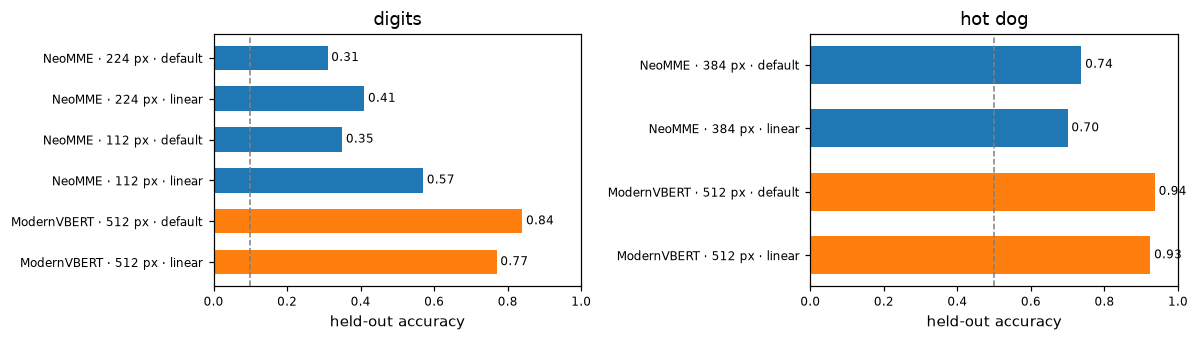

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (task, chance) in zip(axs, (("digits", 0.1), ("hot dog", 0.5))):
    t = table.loc[task, "accuracy"].astype(float)
    labels = [f"{enc} · {img} · {head}" for enc, img, head in t.index]
    colors = ["C0" if enc == "NeoMME" else "C1" for enc, _, _ in t.index]
    ax.barh(labels[::-1], t.values[::-1], color=colors[::-1], height=0.6)
    for i, v in enumerate(t.values[::-1]): ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
    ax.axvline(chance, color="gray", ls="--", lw=1); ax.set(xlim=(0, 1), title=task, xlabel="held-out accuracy"); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

ModernVBERT's heads are the most accurate on both tasks, by margins far beyond the ±0.05 of these splits. On the digits its default head reaches 0.84. NeoMME's best run, the linear head on digits shrunk to 112 pixels, reaches 0.57, and its default head at 224 pixels 0.31. On the photos ModernVBERT reaches 0.94, against NeoMME's 0.74. Both best runs are picked on these test images, and NeoMME's digit size was picked on them too, in its tutorial's sweep, so NeoMME's 0.57 is the most flattered number here. ModernVBERT's probabilities are better too, with a Brier score of 0.26 on the digits against NeoMME's best of 0.64, and 0.09 on the photos against 0.33. The calibration error is lower for ModernVBERT on the photos (0.04 to 0.05 against 0.09 to 0.13), and alike for the two on the digits (0.10 to 0.19).

## What each costs

What each encoder, task and size cost: the tokens a row takes, the time to encode a row once (the whole cost of a frozen encoder, since the head then trains on stored vectors), and the encoder's size. Then the time each head took to fit:

In [ ]:
cost_table = pd.DataFrame(costs).T
cost_table.index.names = ["task", "encoder", "image"]
display(cost_table.astype(float).round(1))
table["fit s"].astype(float).round(2).unstack("head")

tokens per row  encode ms per row  encoder params (M)
task    encoder     image                                                        
digits  NeoMME      224 px           100.0               21.9               262.9
                    112 px            64.0               15.1               262.9
        ModernVBERT 512 px           102.0               88.3               252.0
hot dog NeoMME      384 px           137.0               31.1               262.9
        ModernVBERT 512 px           100.0               89.6               252.0

head                        default  linear
task    encoder     image                  
digits  ModernVBERT 512 px     7.33    0.11
        NeoMME      112 px     7.67    0.15
                    224 px     7.11    0.13
hot dog ModernVBERT 512 px     5.75    0.05
        NeoMME      384 px     5.82    0.06

ModernVBERT is the slower encoder. It takes 88 to 90 ms to encode a row, and NeoMME 15 to 31 ms, so three to six times less. The rows are about as long (ModernVBERT's 100 to 102 tokens, NeoMME's 64 to 137), and the encoders are about the same size, 252M and 263M parameters. The difference is the image tower. SigLIP2 reads a 512-pixel tile as 1,024 patches before the pixel shuffle folds them into 64 tokens, while NeoMME's patches are its tokens, 16 to 96 of them here. Once the anchors are cached, the heads cost the same on both: about 6 to 8 seconds for 30 epochs of the default head, and a tenth of a second for the linear head. With a frozen encoder the difference is paid once per image, which for these few hundred images is a few seconds.

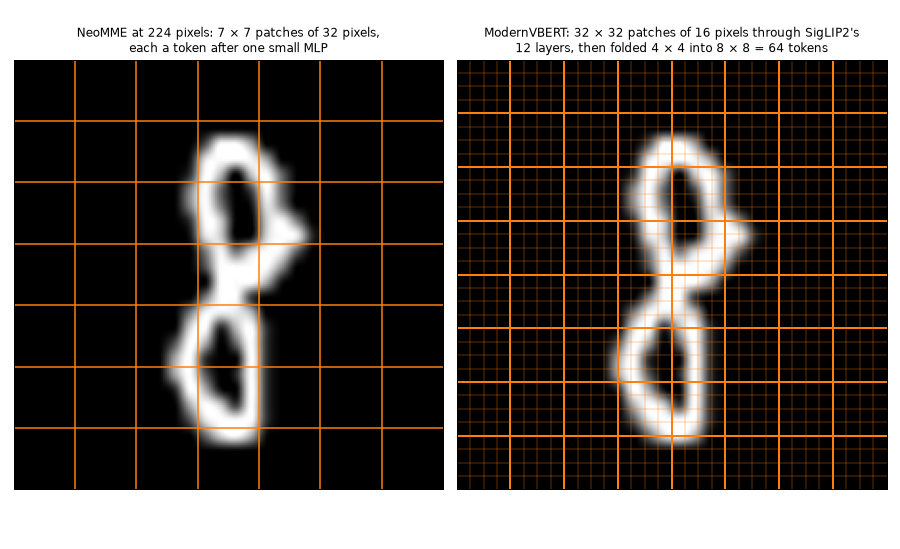

In [ ]:
#| code-fold: true
#| code-summary: figure code
digit = PILImage.open(train[0]["state"]["image"]).convert("RGB")
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 6.1))
a.imshow(digit.resize((224, 224), PILImage.BICUBIC)); b.imshow(digit.resize((512, 512), PILImage.BICUBIC))
for k in range(1, 7): a.axhline(k * 32 - 0.5, color="C1", lw=1.2); a.axvline(k * 32 - 0.5, color="C1", lw=1.2)
for k in range(1, 32): b.axhline(k * 16 - 0.5, color="C1", lw=0.3); b.axvline(k * 16 - 0.5, color="C1", lw=0.3)
for k in range(1, 8): b.axhline(k * 64 - 0.5, color="C1", lw=1.6); b.axvline(k * 64 - 0.5, color="C1", lw=1.6)
a.set_title("NeoMME at 224 pixels: 7 × 7 patches of 32 pixels,\neach a token after one small MLP", fontsize=9.5)
b.set_title("ModernVBERT: 32 × 32 patches of 16 pixels through SigLIP2's\n12 layers, then folded 4 × 4 into 8 × 8 = 64 tokens", fontsize=9.5)
for ax in (a, b): ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); show_figure(fig)

The same digit, as each encoder takes it in. NeoMME spends almost nothing on the image before its encoder: 49 patches become 49 tokens through one small MLP, and its 17 layers do all the reading. ModernVBERT first runs a 12-layer vision transformer over 1,024 patches, 16 times as many positions as the 64 tokens it hands on, and that is where most of its longer encoding time goes.

## Where the mistakes fall

For each task, the best run of each encoder (by held-out accuracy) on the same test images. Are they wrong on the same images or on different ones? If they err apart, averaging their probabilities should beat both:

In [ ]:
def best(task, model):
    "The key of an encoder's most accurate run on a task"
    return max((k for k in results if k[0] == task and k[1] == model), key=lambda k: results[k]["accuracy"])

def right(key):
    "Whether each test answer of a run is right"
    task, te = key[0], TASKS[key[0]][1]
    if task == "digits": return np.array([a["digit"]["choice"] == r["gold"]["digit"]["label"] for a, r in zip(answers[key], te)])
    return np.array([(a["hot_dog"]["noul"] >= 0.5) == (r["gold"]["hot_dog"]["noul"] == 1) for a, r in zip(answers[key], te)])

def ensemble(task, ka, kb):
    "The accuracy of the average of two runs' probabilities"
    te = TASKS[task][1]
    if task == "digits":
        keys = [str(d) for d in range(10)]
        p = lambda k: np.array([[a["digit"]["probabilities"][c] for c in keys] for a in answers[k]])
        pred = (p(ka) + p(kb)).argmax(1)
        return float(np.mean([keys[i] == r["gold"]["digit"]["label"] for i, r in zip(pred, te)]))
    p = lambda k: np.array([a["hot_dog"]["noul"] for a in answers[k]])
    return float(np.mean(((p(ka) + p(kb)) / 2 >= 0.5) == np.array([r["gold"]["hot_dog"]["noul"] == 1 for r in te])))

agree = {}
for task in TASKS:
    kn, km = best(task, "NeoMME"), best(task, "ModernVBERT")
    rn, rm = right(kn), right(km)
    agree[task] = {"NeoMME's best run": " · ".join(kn[2:]), "ModernVBERT's best run": " · ".join(km[2:]),
                   "both right": int((rn & rm).sum()), "only NeoMME": int((rn & ~rm).sum()), "only ModernVBERT": int((~rn & rm).sum()),
                   "both wrong": int((~rn & ~rm).sum()), "NeoMME": round(rn.mean(), 3), "ModernVBERT": round(rm.mean(), 3),
                   "the two averaged": round(ensemble(task, kn, km), 3)}
pd.DataFrame(agree)

,digits,hot dog
NeoMME's best run,112 px · linear,384 px · default
ModernVBERT's best run,512 px · default,512 px · default
both right,51,56
only NeoMME,6,3
only ModernVBERT,33,19
both wrong,10,2
NeoMME,0.57,0.738
ModernVBERT,0.84,0.938
the two averaged,0.85,0.95


ModernVBERT gets most of NeoMME's mistakes right, but most of its own mistakes defeat NeoMME too, so averaging the two hardly helps. On the digits, 33 of the 100 are right only for ModernVBERT, 6 only for NeoMME, and 10 defeat both: 10 of ModernVBERT's 16 mistakes, where two encoders erring independently would share about 7. The average of the two runs' probabilities reaches 0.85, one point above ModernVBERT alone. On the photos, 19 are right only for ModernVBERT, 3 only for NeoMME, and 2 defeat both, and the average reaches 0.95 against ModernVBERT's 0.94. An ensemble would pay NeoMME's cost again for about a point.

Recall per digit, the share of each digit's ten test images the best run of each encoder gets right:

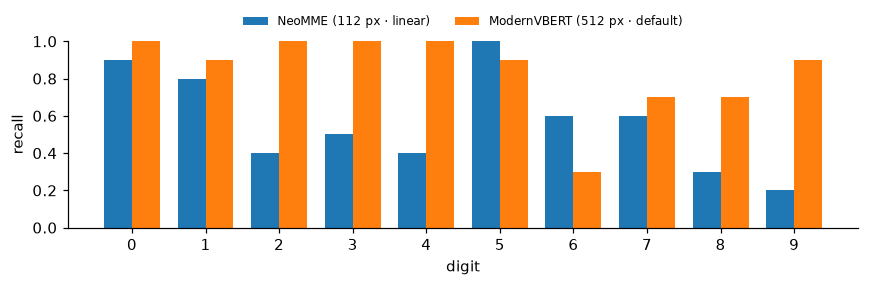

In [ ]:
#| code-fold: true
#| code-summary: figure code
gold = np.array([r["gold"]["digit"]["label"] for r in test])
fig, ax = plt.subplots(figsize=(8, 2.8)); x = np.arange(10)
for k, (model, c) in enumerate((("NeoMME", "C0"), ("ModernVBERT", "C1"))):
    rr = right(best("digits", model))
    ax.bar(x + (k - 0.5) * 0.38, [rr[gold == str(d)].mean() for d in range(10)], 0.38, color=c, label=f"{model} ({' · '.join(best('digits', model)[2:])})")
ax.set(xticks=x, xlabel="digit", ylabel="recall", ylim=(0, 1)); ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.2))
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

NeoMME does better on two digits: the 5s, all ten against ModernVBERT's nine, and the 6s, six against three. On the 2s, 3s, 4s, 8s and 9s, ModernVBERT finds seven to ten of each digit's ten, where NeoMME finds two to five.

The test photos the two encoders answer differently, with each encoder's probability of *hot dog*:

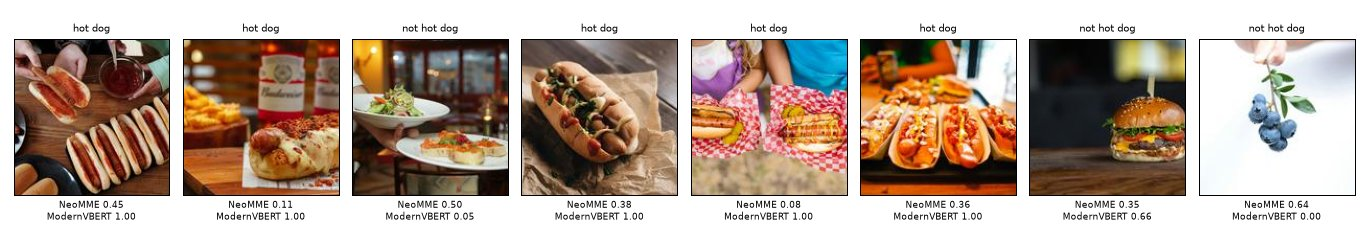

In [ ]:
#| code-fold: true
#| code-summary: figure code
kn, km = best("hot dog", "NeoMME"), best("hot dog", "ModernVBERT")
differ = [i for i in range(len(htest)) if right(kn)[i] != right(km)[i]][:8]
fig, axs = plt.subplots(1, max(1, len(differ)), figsize=(1.9 * max(1, len(differ)), 2.6), squeeze=False)
for ax, i in zip(axs[0], differ):
    r = htest[i]; ax.imshow(square(PILImage.open(r["state"]["image"]))); ax.set_xticks([]); ax.set_yticks([])
    truth = "hot dog" if r["gold"]["hot_dog"]["noul"] == 1 else "not hot dog"
    ax.set_title(truth, fontsize=8)
    ax.set_xlabel(f"NeoMME {answers[kn][i]['hot_dog']['noul']:.2f}\nModernVBERT {answers[km][i]['hot_dog']['noul']:.2f}", fontsize=7)
plt.tight_layout(); show_figure(fig, "jpeg")

Seven of the eight go to ModernVBERT. Five are hot dogs that NeoMME doubted, at 0.08 to 0.45, and ModernVBERT gave 1.00. Another is a plate of other food that NeoMME put at exactly 0.50, which counts as *hot dog*, and ModernVBERT at 0.05. The last is a sprig of blueberries that NeoMME calls a hot dog at 0.64. The one NeoMME gets right is a burger, which ModernVBERT calls a hot dog at 0.66.

## The geometry of the anchors

The NeoMME tutorial found one channel carrying almost the whole length of every NeoMME vector, which is why the application standardises the anchors before the head. The same look at both encoders' training anchors from the digits' default-head runs (for NeoMME, the 112-pixel run, the second of its two):

                            NeoMME  ModernVBERT
width                         1024          768
norm                   32.0 ± 0.00  49.0 ± 0.27
top channel                    139          256
its share of the norm        96.4%        57.6%


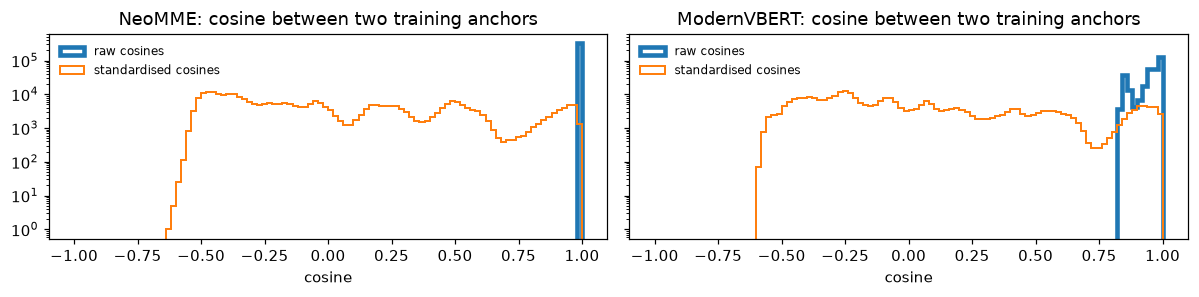

In [ ]:
def geometry(A):
    "Norm, the channel with the largest mean and its share of the norm, and the cosines between anchors, raw and standardised"
    norm, mu, sd = np.linalg.norm(A, axis=1), A.mean(0), A.std(0)
    c = int(np.abs(mu).argmax())
    cos = lambda X: (lambda Y: (Y @ Y.T)[np.triu_indices(len(Y), 1)])(X / np.linalg.norm(X, axis=1, keepdims=True))
    return {"width": A.shape[1], "norm": f"{norm.mean():.1f} ± {norm.std():.2f}", "top channel": c,
            "its share of the norm": f"{np.mean(np.abs(A[:, c]) / norm):.1%}", "raw cosines": cos(A), "standardised cosines": cos((A - mu) / np.maximum(sd, 1e-6))}

geo = {model: geometry(anchors[("digits", model)]) for model in ENCODERS}
print(pd.DataFrame({m: {k: v for k, v in g.items() if "cosines" not in k} for m, g in geo.items()}).to_string())
fig, axs = plt.subplots(1, 2, figsize=(11, 2.8), sharey=True)
for ax, (model, g) in zip(axs, geo.items()):
    for key, lw in (("raw cosines", 3), ("standardised cosines", 1.3)): ax.hist(g[key], bins=100, range=(-1, 1), histtype="step", lw=lw, label=key)
    ax.set(title=f"{model}: cosine between two training anchors", yscale="log", xlabel="cosine"); ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

Both encoders put most of each anchor's length in one channel, NeoMME far more than ModernVBERT. NeoMME's channel 139 holds 96% of a vector's length, every vector is exactly 32 long, and any two raw anchors have a cosine of 0.99. ModernVBERT's channel 256 holds 58%, and its raw cosines spread from 0.8 to 1. Standardised, both spread out between −0.6 and 1, and that is why the application standardises both encoders' anchors. In the tutorials it lifted the digits' default head by 0.17 on each encoder: from 0.14 to 0.31 on NeoMME, and from 0.67 to 0.84 on ModernVBERT.

## LoRA

LoRA trains adapters inside the encoder, so it has no cache, and on MPS it isn't bit-for-bit repeatable from one run to the next. Rather than train four more models here, the table gathers the LoRA results of the two tutorials, which used the same records and the same recipe (rank 8, 20 epochs at 10⁻³):

| | NeoMME, LoRA | ModernVBERT, LoRA |
| --- | --- | --- |
| digits | 0.33, trained in 146 s | 0.84, trained in 358 s |
| hot dog | 0.725, trained in 176 s | 0.963, trained in 287 s |
| adapters | `q_proj`, `k_proj`, `v_proj`, `o_proj` in 17 layers: 905,216 weights | `Wqkv` and `Wo` in the text tower's 22 layers: 811,008 weights |

LoRA changes neither ranking. ModernVBERT's LoRA matches its default head on the digits (0.84), and on the photos it scores 0.96 against the default head's 0.94, with better-calibrated probabilities on both. NeoMME's LoRA lands between its two heads on both tasks. ModernVBERT's LoRA takes 1.6 to 2.5 times as long to train, because its image tower runs at every step: frozen, but not cached.

## What this shows

- **On these two tasks ModernVBERT is the better encoder under the sysone head, by a wide margin.** It reaches 0.84 against NeoMME's best of 0.57 on the digits, and 0.94 against 0.74 on the photos, with better-calibrated probabilities. It gets there with the application's defaults and no tuning of the image size, where NeoMME needed its digits shrunk to 112 pixels to reach 0.57.
- **It costs more to run.** Encoding a row takes three to six times as long, 88 to 90 ms against 15 to 31. With a frozen encoder that is paid once per image, but under LoRA it is paid at every step.
- **ModernVBERT gets most of NeoMME's mistakes right, and most of its own are NeoMME's too**, so an average of the two adds only about a point to ModernVBERT alone.
- **Both encoders' vectors have a dominant channel,** NeoMME's far more so, and standardising the anchors, the application's default, lifted both by 0.17 on the digits.

What this doesn't test is documents. NeoMME was built for screenshots and pages, with its two-axis positions and its small patches, and ModernVBERT was trained on documents too, for retrieval. Tiny digits and stock photos favour an image tower trained on natural images, and SigLIP2 is one. A comparison on pages, such as the Mind2Web screens of the [screens](../21_screens.ipynb) notebook, is the one that would decide between them for sysone's own use. The [screens tutorial](web_screens.ipynb) ran it as a pilot, and with the [text tutorial](web_text.ipynb) it moved the multimodal application's default to ModernVBERT (the [NeoMME notebook](../20_neomme.ipynb#which-encoder-by-default) has the evidence).

In [ ]:
print(f"the whole notebook: {(time.time() - t_start) / 60:.1f} minutes · {memory_line()}")

the whole notebook: 2.2 minutes · peak RSS 2.5 GB · MPS 0.2 GB
